In [1]:
import time
import statistics
import heapq

def merge_k_sorted_arrays(arrays):
    heap = []
    result = []

    # Insert first element of each array
    for i in range(len(arrays)):
        if arrays[i]:
            heapq.heappush(heap, (arrays[i][0], i, 0))

    while heap:
        value, array_index, element_index = heapq.heappop(heap)
        result.append(value)

        next_index = element_index + 1

        if next_index < len(arrays[array_index]):
            next_value = arrays[array_index][next_index]
            heapq.heappush(
                heap,
                (next_value, array_index, next_index)
            )

    return result


sizes = list(range(100, 10001, 500))
times = []
runs = 5

k = 10

for n in sizes:
    # Total elements = n, distributed among k sorted arrays
    arrays = []

    for i in range(k):
        start = i * (n // k)
        end = (i + 1) * (n // k)
        arrays.append(list(range(start, end)))

    measurements = []

    for _ in range(runs):
        start = time.perf_counter_ns()
        merge_k_sorted_arrays(arrays)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

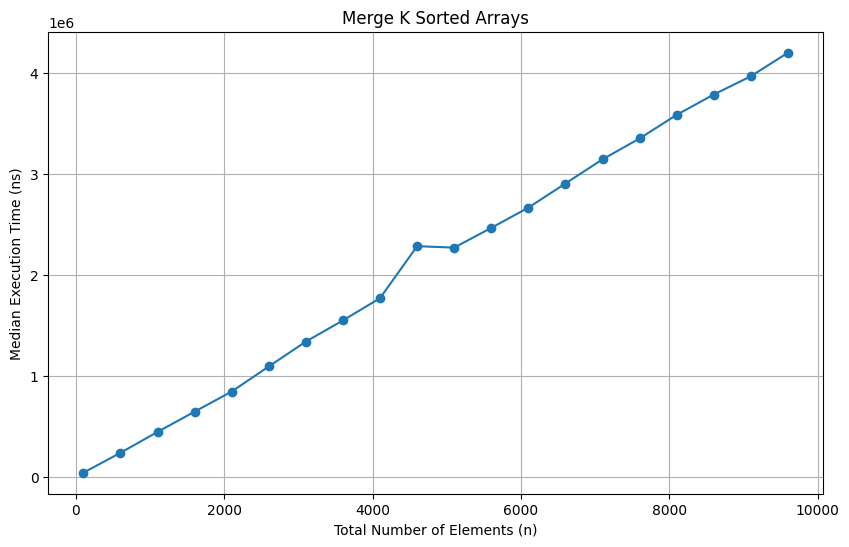

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Merge K Sorted Arrays")
plt.xlabel("Total Number of Elements (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()